In [22]:
import pandas as pd
from transformers import BertTokenizer, BertForTokenClassification
import torch
from pathlib import Path
import torch.nn as nn
from torch.optim import AdamW, lr_scheduler
import numpy as np
import re
import sqlite3
from torch.cuda import is_available
from sklearn.preprocessing import label_binarize
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect('expense_tracker.db')
c = conn.cursor()

c.execute('''CREATE TABLE IF NOT EXISTS users
             (user_id INTEGER PRIMARY KEY AUTOINCREMENT, username TEXT, password TEXT)''')

c.execute('''CREATE TABLE IF NOT EXISTS transactions
             (transaction_id INTEGER PRIMARY KEY AUTOINCREMENT, user_id INTEGER, description TEXT, expense_type TEXT, amount REAL, FOREIGN KEY(user_id) REFERENCES users(user_id))''')

In [3]:
df = pd.read_csv("/kaggle/input/expenses/FinalDataset.csv")
texts = df["Expense Description"].tolist()
labels = df["Expense Type"].tolist()

labels = np.array(labels, dtype=np.str_)

labels = np.where(pd.isnull(labels), '', labels)

expense_types = ["Food", "Groceries", "Parking", "Dining", "Entertainment", "Fuel",
                 "Shopping", "Rent", "Utilities", "Electronics", "Clothing", "Charity",
                 "Transportation", "Subscription", "Healthcare", "Travel", "Fitness and Sports",
                 "Home", "Business", "Education", "Beauty", "Gifts", "Insurance",
                 "Taxes", "Loan Repayment", "Savings", "Miscellaneous", "Pet Care",
                 "Hobbies", "Books"]

In [4]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# tokenized_texts = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
# label_tensors = torch.tensor([expense_types.index(label) for label in labels], dtype=torch.long)
# dataset = TensorDataset(tokenized_texts["input_ids"], tokenized_texts["attention_mask"], label_tensors)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [5]:
train_texts, val_texts, train_labels, val_labels = train_test_split(texts, labels, test_size=0.2, random_state=42)

train_tokenized_texts = tokenizer(train_texts, padding=True, truncation=True, return_tensors="pt")
train_label_tensors = torch.tensor([expense_types.index(label) for label in train_labels], dtype=torch.long)
train_dataset = TensorDataset(train_tokenized_texts["input_ids"], train_tokenized_texts["attention_mask"], train_label_tensors)

val_tokenized_texts = tokenizer(val_texts, padding=True, truncation=True, return_tensors="pt")
val_label_tensors = torch.tensor([expense_types.index(label) for label in val_labels], dtype=torch.long)
val_dataset = TensorDataset(val_tokenized_texts["input_ids"], val_tokenized_texts["attention_mask"], val_label_tensors)

In [6]:
num_labels = len(expense_types)
learning_rate = 2e-5
batch_size = 8
num_epochs = 10
dropout_rate = 0.2

In [7]:
# model = BertForTokenClassification.from_pretrained("bert-base-uncased", num_labels=num_labels) 
# model.to(device)
# model.classifier = nn.Linear(model.config.hidden_size, num_labels).to(device)
# optimizer = AdamW(model.parameters(), lr=learning_rate)
# scheduler = lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)
# criterion = nn.CrossEntropyLoss()
# dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [8]:
model = BertForTokenClassification.from_pretrained("bert-large-uncased", num_labels=num_labels)
model.classifier = nn.Sequential(
    nn.Dropout(dropout_rate),
    nn.Linear(model.config.hidden_size, num_labels)
).to(device)

model.train()
for param in model.bert.parameters():
    param.requires_grad = True

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-large-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
optimizer = AdamW(model.parameters(), lr=learning_rate)
scheduler = lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)
criterion = nn.CrossEntropyLoss()

In [10]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [11]:
def calculate_accuracy(logits, labels):
    predictions = torch.argmax(logits, axis=-1).cpu().numpy()
    correct = (predictions == labels.cpu().numpy()).sum()
    total = len(labels)
    accuracy = (correct / total) * 100
    return accuracy

In [12]:
def train_model(model, optimizer, scheduler, num_epochs, train_dataloader, val_dataloader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    best_val_loss = float('inf')
    best_model_weights = None

    for epoch in range(num_epochs):
        total_train_loss = 0.0
        total_train_correct = 0
        total_train_samples = 0
        model.train()

        for batch in train_dataloader:
            b_input_ids, b_attn_mask, b_labels = batch
            b_input_ids = b_input_ids.to(device)
            b_attn_mask = b_attn_mask.to(device)
            b_labels = b_labels.to(device)

            optimizer.zero_grad()

            outputs = model(b_input_ids, attention_mask=b_attn_mask)

            logits = outputs.logits
            logits = logits.view(-1, b_input_ids.size(1), num_labels)
            logits = logits[:, -1, :]

            loss = criterion(logits, b_labels)

            total_train_loss += loss.item()
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            
            optimizer.step()

            total_train_correct += (torch.argmax(logits, axis=-1) == b_labels).sum().item()
            total_train_samples += len(b_labels)

        train_accuracy = (total_train_correct / total_train_samples) * 100
        train_losses.append(total_train_loss / len(train_dataloader))
        train_accuracies.append(train_accuracy)

        total_val_loss = 0.0
        total_val_correct = 0
        total_val_samples = 0
        model.eval()

        with torch.no_grad():
            for batch in val_dataloader:
                b_input_ids, b_attn_mask, b_labels = batch
                b_input_ids = b_input_ids.to(device)
                b_attn_mask = b_attn_mask.to(device)
                b_labels = b_labels.to(device)

                outputs = model(b_input_ids, attention_mask=b_attn_mask)

                logits = outputs.logits
                logits = logits.view(-1, b_input_ids.size(1), num_labels)
                logits = logits[:, -1, :]

                loss = criterion(logits, b_labels)

                total_val_loss += loss.item()
                total_val_correct += (torch.argmax(logits, axis=-1) == b_labels).sum().item()
                total_val_samples += len(b_labels)

        val_accuracy = (total_val_correct / total_val_samples) * 100
        val_losses.append(total_val_loss / len(val_dataloader))
        val_accuracies.append(val_accuracy)

        if val_losses[-1] < best_val_loss:
            best_val_loss = val_losses[-1]
            best_model_weights = model.state_dict()

        print(f'Epoch {epoch + 1}/{num_epochs}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]:.2f}%, Validation Loss: {val_losses[-1]}, Validation Accuracy: {val_accuracies[-1]:.2f}%')

        scheduler.step()

    model.load_state_dict(best_model_weights)

    return model, train_losses, train_accuracies, val_losses, val_accuracies


In [13]:
model, train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    model, optimizer, scheduler, num_epochs, train_dataloader, val_dataloader)

Epoch 1/10, Train Loss: 2.1826532437251163, Train Accuracy: 48.97%, Validation Loss: 0.4239742887707857, Validation Accuracy: 94.69%
Epoch 2/10, Train Loss: 0.3634477441127484, Train Accuracy: 96.37%, Validation Loss: 0.2304989199798841, Validation Accuracy: 97.58%
Epoch 3/10, Train Loss: 0.24676368496595666, Train Accuracy: 97.94%, Validation Loss: 0.2185648099447672, Validation Accuracy: 98.07%
Epoch 4/10, Train Loss: 0.2369610724540857, Train Accuracy: 98.43%, Validation Loss: 0.21749182833501926, Validation Accuracy: 98.07%
Epoch 5/10, Train Loss: 0.23236813919188884, Train Accuracy: 97.94%, Validation Loss: 0.21743260109080717, Validation Accuracy: 98.07%
Epoch 6/10, Train Loss: 0.2410425664140628, Train Accuracy: 98.43%, Validation Loss: 0.21743183167508015, Validation Accuracy: 98.07%
Epoch 7/10, Train Loss: 0.23539610880498701, Train Accuracy: 98.43%, Validation Loss: 0.21743184743592373, Validation Accuracy: 98.07%
Epoch 8/10, Train Loss: 0.23688649493627822, Train Accuracy: 9

In [14]:
torch.save(model, 'expense_model.pt')

In [17]:
def extract_amount(text):
    numbers = re.findall(r'\d+', text)
    if numbers:
        return float(numbers[0])
    else:
        return 0
    
model = torch.load('/kaggle/working/expense_model.pt')

def predict_expense(text, tokenizer, model):
    input_ids = tokenizer.encode(text, return_tensors="pt", truncation=True).to(device)
    output = model(input_ids)
    predictions = torch.argmax(output.logits, axis=-1).cpu().numpy().tolist()[0] 
    return expense_types[predictions[1]]

<ipython-input-17-f375c827ecf3>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('/kaggle/working/expense_model.pt')


F1-score: 0.98
Recall: 0.98
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00         3
           3       0.80      1.00      0.89         8
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00         1
           6       1.00      0.60      0.75         5
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         1
           9       1.00      1.00      1.00         6
          10       0.80      1.00      0.89         8
          11       1.00      1.00      1.00         7
          12       1.00      1.00      1.00         7
          13       1.00      1.00      1.00         8
          14       1.00      1.00      1.00         8
          15       1.00      1.00      1.00        13
          16       1.00      1

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


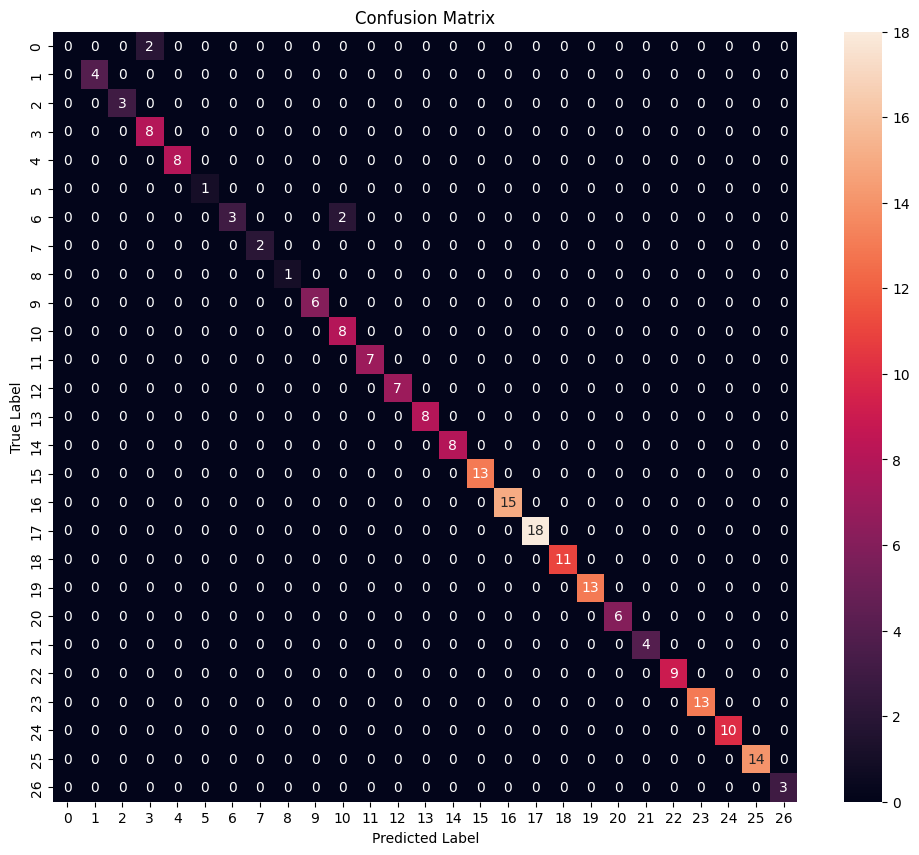

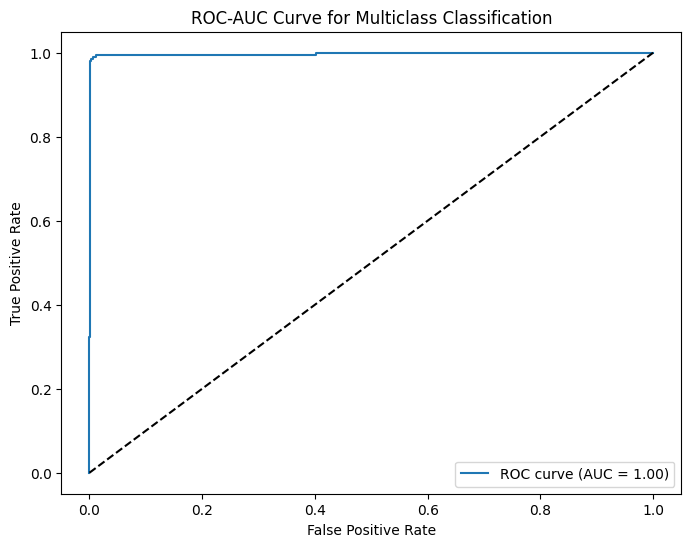

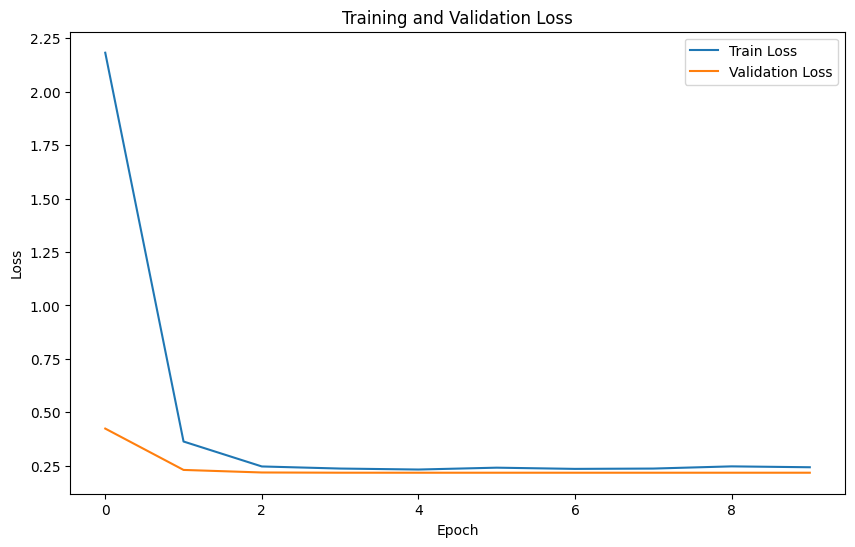

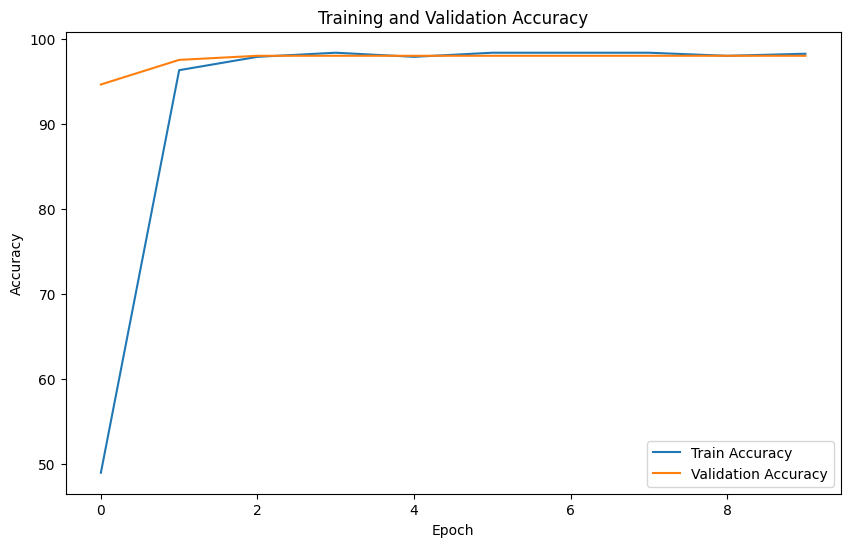

In [23]:
def evaluate_model(model, dataloader, device, train_losses=None, val_losses=None, train_accuracies=None, val_accuracies=None):
    model.eval()
    true_labels = []
    predicted_labels = []
    predicted_probs = []

    with torch.no_grad():
        for batch in dataloader:
            b_input_ids, b_attn_mask, b_labels = batch
            b_input_ids = b_input_ids.to(device)
            b_attn_mask = b_attn_mask.to(device)
            b_labels = b_labels.to(device)

            outputs = model(b_input_ids, attention_mask=b_attn_mask)
            logits = outputs.logits
            logits = logits.view(-1, b_input_ids.size(1), num_labels)
            logits = logits[:, -1, :]  # Get the last token's logits

            predictions = torch.argmax(logits, dim=-1).cpu().numpy()
            true_labels.extend(b_labels.cpu().numpy())
            predicted_labels.extend(predictions)
            predicted_probs.extend(torch.softmax(logits, dim=-1).cpu().numpy())

    predicted_probs = np.array(predicted_probs)  # Convert to numpy array
    true_labels = np.array(true_labels)
    true_labels_binary = label_binarize(true_labels, classes=list(range(num_labels)))

    # Calculate evaluation metrics
    f1 = f1_score(true_labels, predicted_labels, average='weighted')
    recall = recall_score(true_labels, predicted_labels, average='weighted')

    print(f"F1-score: {f1:.2f}")
    print(f"Recall: {recall:.2f}")

    # Print classification report
    print("Classification Report:")
    print(classification_report(true_labels, predicted_labels))

    # Plot confusion matrix
    conf_matrix = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(12, 10))
    sns.heatmap(conf_matrix, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    # Calculate and plot ROC-AUC curve for multiclass classification
    fpr, tpr, _ = roc_curve(true_labels_binary.ravel(), predicted_probs.ravel())
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curve for Multiclass Classification')
    plt.legend()
    plt.show()

    # Plot accuracy and loss graphs (if available)
    if train_losses is not None and val_losses is not None:
        plt.figure(figsize=(10, 6))
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss')
        plt.legend()
        plt.show()

    if train_accuracies is not None and val_accuracies is not None:
        plt.figure(figsize=(10, 6))
        plt.plot(train_accuracies, label='Train Accuracy')
        plt.plot(val_accuracies, label='Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.legend()
        plt.show()

evaluate_model(model, val_dataloader, device, train_losses, val_losses, train_accuracies, val_accuracies)

In [ ]:
new_text = input("Enter expense description: ")
predicted_type = predict_expense(new_text, tokenizer, model)
predicted_amt = extract_amount(new_text)

print("Predicted Expense Details:")
print(f"- Description: {new_text}")
print(f"- Type: {predicted_type}")
print(f"- Amount: {predicted_amt}")

confirm = input("Is this correct? (y/n): ")

if confirm.lower() == 'y':
    expense_type = predicted_type
    expense_amount = predicted_amt
else:
    print("Select the correct expense type:")
    for i, type in enumerate(expense_types):
        print(f"{i} - {type}")
    type_idx = int(input("Enter number: "))
    expense_type = expense_types[type_idx]
    expense_amount = float(input("Enter the correct expense amount: "))

new_row = [new_text, expense_type, expense_amount]
user_data_file = Path('user_expenses.csv')

if user_data_file.exists():
    user_data = pd.read_csv(user_data_file)
else:
    user_data = pd.DataFrame(columns=['Description', 'Expense Type', 'Amount'])

new_row_df = pd.DataFrame([new_row], columns=user_data.columns)
user_data = pd.concat([user_data, new_row_df], ignore_index=True)

user_data.to_csv(user_data_file, index=False)
print("Entry saved to expenses file!")

In [ ]:
def sign_up():
    print("Sign Up")
    username = input("Enter a username: ")
    c.execute("SELECT * FROM users WHERE username = ?", (username,))
    existing_user = c.fetchone()
    
    if existing_user:
        print("Username already exists. Please choose a different username.")
    else:
        password = input("Enter a password: ")
        c.execute("INSERT INTO users (username, password) VALUES (?, ?)", (username, password))
        conn.commit()
        print("User created successfully!")

In [ ]:
def login():
    print("Login")
    username = input("Enter your username: ")
    password = input("Enter your password: ")
    c.execute("SELECT * FROM users WHERE username = ? AND password = ?", (username, password))
    user = c.fetchone()
    if user:
        print("Login successful!")
        return user[0] 
    else:
        print("Invalid username or password.")
        return None

In [ ]:
def add_transaction(user_id):
    new_text = input("Enter expense description: ")
    predicted_type = predict_expense(new_text, tokenizer, model)
    predicted_amt = extract_amount(new_text)

    print("Predicted Expense Details:")
    print(f"- Description: {new_text}")
    print(f"- Type: {predicted_type}")
    print(f"- Amount: {predicted_amt}")

    confirm = input("Is this correct? (y/n): ")

    if confirm.lower() == 'y':
        expense_type = predicted_type
        expense_amount = predicted_amt
    else:
        print("Select the correct expense type:")
        for i, type in enumerate(expense_types):
            print(f"{i} - {type}")
        type_idx = int(input("Enter number: "))
        expense_type = expense_types[type_idx]
        expense_amount = float(input("Enter the correct expense amount: "))

    c.execute("INSERT INTO transactions (user_id, description, expense_type, amount) VALUES (?, ?, ?, ?)",
              (user_id, new_text, expense_type, expense_amount))
    conn.commit()
    print("Transaction added successfully!")

In [ ]:
def view_transactions(user_id):
    c.execute("SELECT description, expense_type, amount FROM transactions WHERE user_id = ?", (user_id,))
    transactions = c.fetchall()
    if transactions:
        print("Transaction History:")
        for transaction in transactions:
            print(f"- Description: {transaction[0]}, Type: {transaction[1]}, Amount: {transaction[2]}")
    else:
        print("No transactions found for this user.")

In [ ]:
def main():
    while True:
        print("\nExpense Tracker")
        print("1. Sign Up")
        print("2. Login")
        print("3. Exit")
        choice = input("Enter your choice (1-3): ")

        if choice == '1':
            sign_up()
        elif choice == '2':
            user_id = login()
            if user_id:
                while True:
                    print("\nUser Menu")
                    print("1. Add Transaction")
                    print("2. View Transaction History")
                    print("3. Logout")
                    user_choice = input("Enter your choice (1-3): ")

                    if user_choice == '1':
                        add_transaction(user_id)
                    elif user_choice == '2':
                        view_transactions(user_id)
                    elif user_choice == '3':
                        break
                    else:
                        print("Invalid choice. Please try again.")
        elif choice == '3':
            break
        else:
            print("Invalid choice. Please try again.")

    conn.close()

if __name__ == "__main__":
    main()

In [ ]:
conn = sqlite3.connect('expense_tracker.db')
c = conn.cursor()
print("User Records:")
c.execute("SELECT * FROM users")
users = c.fetchall()
if users:
    for user in users:
        print(f"User ID: {user[0]}, Username: {user[1]}, Password: {user[2]}")
else:
    print("No user records found.")
print("\n") 
print("Transaction Records:")
c.execute("SELECT t.transaction_id, u.username, t.description, t.expense_type, t.amount "
          "FROM transactions t "
          "JOIN users u ON t.user_id = u.user_id")
transactions = c.fetchall()
if transactions:
    for transaction in transactions:
        print(f"Transaction ID: {transaction[0]}, Username: {transaction[1]}, Description: {transaction[2]}, Type: {transaction[3]}, Amount: {transaction[4]}")
else:
    print("No transaction records found.")
conn.close()

In [ ]:
conn = sqlite3.connect('expense_tracker.db')
c = conn.cursor()
confirm = input("Confirm (y/n)")
if confirm.lower() == 'y':
    c.execute("DELETE FROM transactions")
    conn.commit()
    print("All transaction records have been removed.")
    c.execute("DELETE FROM users")
    conn.commit()
    print("All user records have been removed.")

    print("Database has been reset.")
else:
    print("Operation canceled.")

conn.close()